In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import StratifiedKFold
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [5]:
df=pd.read_csv("C:/Users/kulal/OneDrive/Documents/Infotact Solution/Predictive_Maintainance/Dataset/ai4i2020.csv")

In [6]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [8]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [9]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

0 ----> No Machine Failure

1 ----> Machine Failure

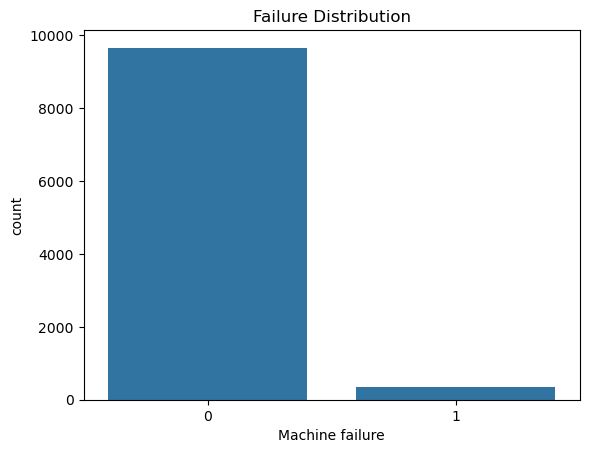

In [12]:
sns.countplot(
    x='Machine failure',
    data=df
)

plt.title("Failure Distribution")
plt.show()

<Axes: >

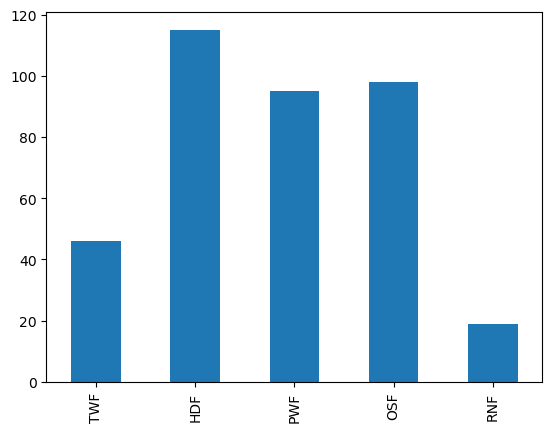

In [13]:
failure_types = ['TWF','HDF','PWF','OSF','RNF']

df[failure_types].sum().plot(kind='bar')

Dropping Failure Types columns and Other Less important columns

In [14]:
df.drop(failure_types,axis=1,inplace=True)

In [15]:
df.drop(['UDI','Product ID'],axis=1,inplace=True)

In [16]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [17]:
df['Type'].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Converting Type to Numerical Using LabelEncoder

In [18]:
le = LabelEncoder()

df['Type'] = le.fit_transform(df['Type'])

In [19]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,2,298.1,308.6,1551,42.8,0,0
1,1,298.2,308.7,1408,46.3,3,0
2,1,298.1,308.5,1498,49.4,5,0
3,1,298.2,308.6,1433,39.5,7,0
4,1,298.2,308.7,1408,40.0,9,0


Exploratory Data Analysis

Histogram

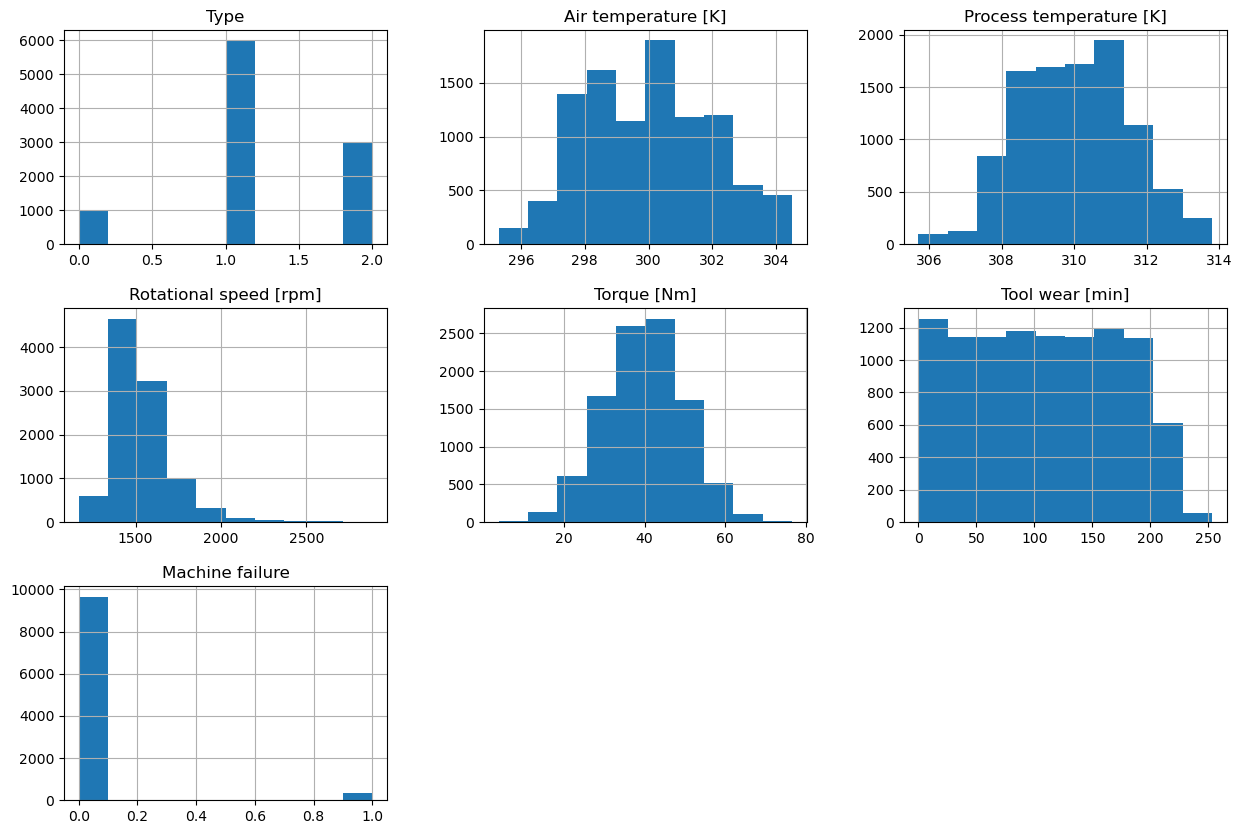

In [20]:
df.hist(figsize=(15,10))
plt.show()

Correlation Matrix

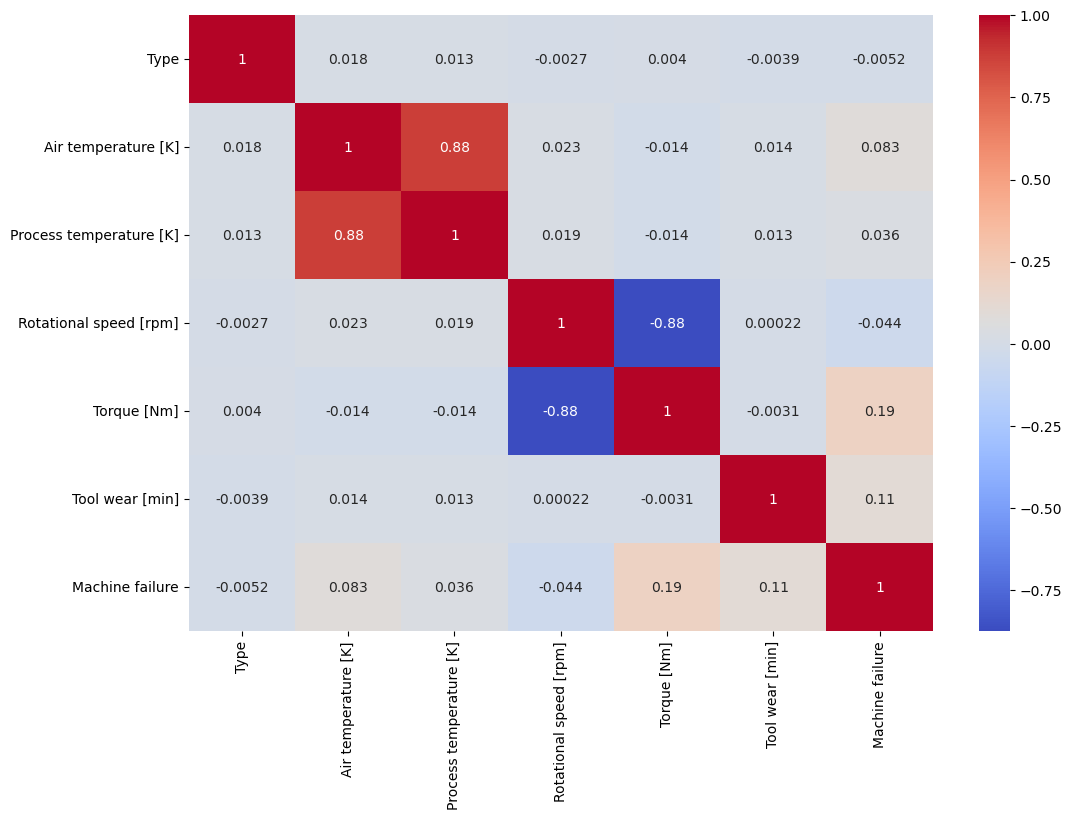

In [21]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [22]:
plt.savefig("C:/Users/kulal/OneDrive/Documents/Infotact Solution/Predictive_Maintainance/Images/correlation_matrix.png")

<Figure size 640x480 with 0 Axes>

Outlier Detection

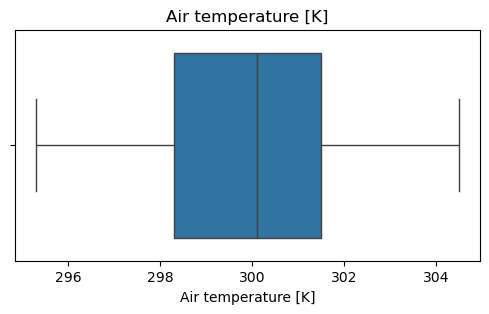

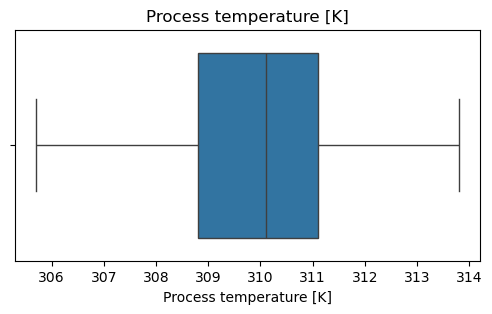

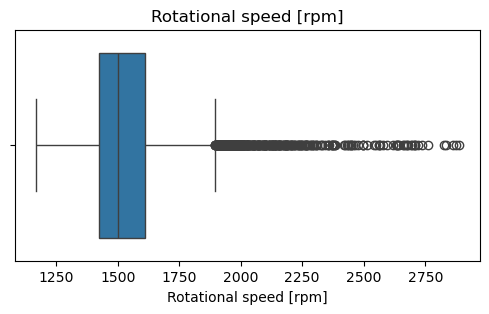

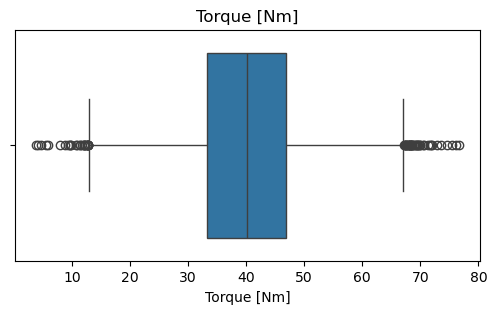

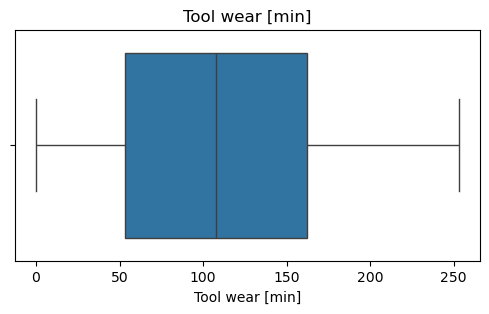

In [23]:
cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for col in cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

Treat Outliers using IQR method

In [24]:
cols = [
    'Rotational speed [rpm]',
    'Torque [Nm]',
]

for col in cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[
        (df[col] >= lower_bound) &
        (df[col] <= upper_bound)
    ]

print("New Shape:", df.shape)

New Shape: (9535, 7)


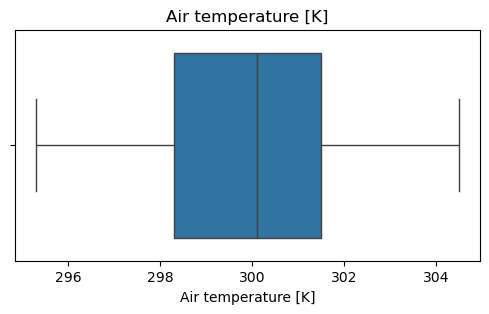

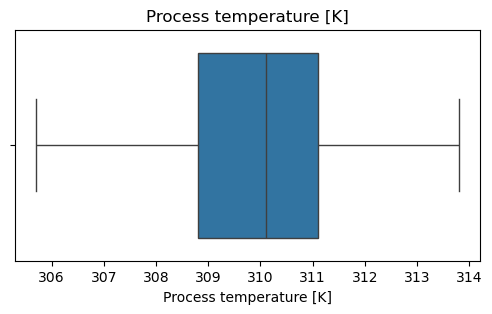

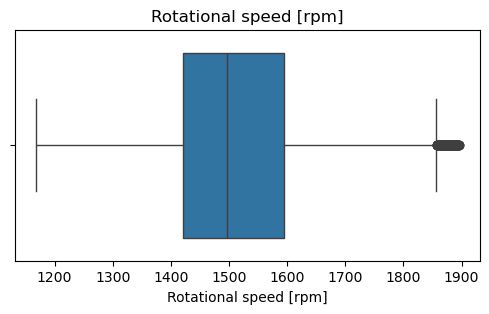

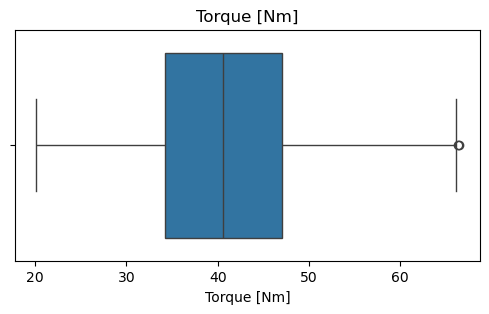

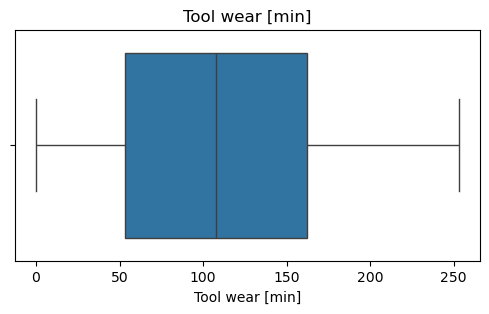

In [25]:
cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

for col in cols:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

Creating Time Index

In [26]:
df['timestamp'] = pd.date_range(
    start='2025-01-01',
    periods=len(df),
    freq='min'
)

In [27]:
df.reset_index(inplace=True)

In [28]:
df.tail()

,index,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,timestamp
9530,9995,2,298.8,308.4,1604,29.5,14,0,2025-01-07 14:50:00
9531,9996,0,298.9,308.4,1632,31.8,17,0,2025-01-07 14:51:00
9532,9997,2,299.0,308.6,1645,33.4,22,0,2025-01-07 14:52:00
9533,9998,0,299.0,308.7,1408,48.5,25,0,2025-01-07 14:53:00
9534,9999,2,299.0,308.7,1500,40.2,30,0,2025-01-07 14:54:00


Rolling Mean for All Sensors

In [29]:
sensor_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]'
]

for col in sensor_cols:
    df[f'{col}_roll_mean'] = df[col].rolling(10, min_periods=1).mean()

Rolling Standard Deviation for All Sensors

In [30]:
for col in sensor_cols:
    df[f'{col}_roll_std'] = df[col].rolling(10, min_periods=1).std()

Rolling Variance for All Sensors

In [31]:
for col in sensor_cols:
    df[f'{col}_roll_var'] = df[col].rolling(10, min_periods=1).var()

Lag Features

In [32]:
for col in sensor_cols:
    df[f'{col}_lag_1'] = df[col].shift(1)
    df[f'{col}_lag_5'] = df[col].shift(5)

Sensor Change Features

In [33]:
for col in sensor_cols:
    df[f'{col}_change'] = df[col].diff()

In [34]:
df=df.dropna()

In [35]:
df

,index,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,timestamp,Air temperature [K]_roll_mean,...,Process temperature [K]_lag_1,Process temperature [K]_lag_5,Rotational speed [rpm]_lag_1,Rotational speed [rpm]_lag_5,Torque [Nm]_lag_1,Torque [Nm]_lag_5,Air temperature [K]_change,Process temperature [K]_change,Rotational speed [rpm]_change,Torque [Nm]_change
5,5,2,298.1,308.6,1425,41.9,11,0,2025-01-01 00:05:00,298.150000,...,308.7,308.6,1408.0,1551.0,40.0,42.8,-0.1,-0.1,17.0,1.9
6,6,1,298.1,308.6,1558,42.4,14,0,2025-01-01 00:06:00,298.142857,...,308.6,308.7,1425.0,1408.0,41.9,46.3,0.0,0.0,133.0,0.5
7,7,1,298.1,308.6,1527,40.2,16,0,2025-01-01 00:07:00,298.137500,...,308.6,308.5,1558.0,1498.0,42.4,49.4,0.0,0.0,-31.0,-2.2
8,8,2,298.3,308.7,1667,28.6,18,0,2025-01-01 00:08:00,298.155556,...,308.6,308.6,1527.0,1433.0,40.2,39.5,0.2,0.1,140.0,-11.6
9,9,2,298.5,309.0,1741,28.0,21,0,2025-01-01 00:09:00,298.190000,...,308.7,308.7,1667.0,1408.0,28.6,40.0,0.2,0.3,74.0,-0.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9530,9995,2,298.8,308.4,1604,29.5,14,0,2025-01-07 14:50:00,298.820000,...,308.3,308.5,1634.0,1527.0,27.9,36.2,0.0,0.1,-30.0,1.6
9531,9996,0,298.9,308.4,1632,31.8,17,0,2025-01-07 14:51:00,298.830000,...,308.4,308.4,1604.0,1827.0,29.5,26.1,0.1,0.0,28.0,2.3
9532,9997,2,299.0,308.6,1645,33.4,22,0,2025-01-07 14:52:00,298.850000,...,308.4,308.4,1632.0,1484.0,31.8,39.2,0.1,0.2,13.0,1.6
9533,9998,0,299.0,308.7,1408,48.5,25,0,2025-01-07 14:53:00,298.860000,...,308.6,308.4,1645.0,1401.0,33.4,47.3,0.0,0.1,-237.0,15.1


In [36]:


df.to_csv(
    "C:/Users/kulal/OneDrive/Documents/Infotact Solution/Predictive_Maintainance/Dataset/week1_processed.csv",
    index=False
)

# WEEK 2 :

In [37]:
df1 = pd.read_csv("C:/Users/kulal/OneDrive/Documents/Infotact Solution/Predictive_Maintainance/Dataset/week1_processed.csv")


Simulate External Context Data

In [38]:
external_df = pd.DataFrame()

external_df['timestamp'] = df1['timestamp']

# Ambient temperature
external_df['ambient_temp'] = (
    25 +
    5*np.sin(np.arange(len(df))/500) +
    np.random.normal(0,1,len(df))
)

# Factory load density
external_df['load_density'] = np.random.randint(
    50,
    100,
    len(df)
)

# Humidity
external_df['humidity'] = np.random.randint(
    40,
    90,
    len(df)
)

# Power fluctuations
external_df['voltage'] = np.random.normal(
    220,
    5,
    len(df)
)

In [39]:
external_df.head()

,timestamp,ambient_temp,load_density,humidity,voltage
0,2025-01-01 00:05:00,26.106804,73,42,215.869721
1,2025-01-01 00:06:00,26.070083,68,64,227.133418
2,2025-01-01 00:07:00,25.166735,62,42,218.831413
3,2025-01-01 00:08:00,26.041542,91,59,214.044550
4,2025-01-01 00:09:00,24.172703,53,88,219.159529


Joining Two Dataframe

In [40]:
combined_df = pd.merge(
    df1,
    external_df,
    on='timestamp',
    how='left'
)

In [41]:
combined_df.head()

,index,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,timestamp,Air temperature [K]_roll_mean,...,Torque [Nm]_lag_1,Torque [Nm]_lag_5,Air temperature [K]_change,Process temperature [K]_change,Rotational speed [rpm]_change,Torque [Nm]_change,ambient_temp,load_density,humidity,voltage
0,5,2,298.1,308.6,1425,41.9,11,0,2025-01-01 00:05:00,298.150000,...,40.0,42.8,-0.1,-0.1,17.0,1.9,26.106804,73,42,215.869721
1,6,1,298.1,308.6,1558,42.4,14,0,2025-01-01 00:06:00,298.142857,...,41.9,46.3,0.0,0.0,133.0,0.5,26.070083,68,64,227.133418
2,7,1,298.1,308.6,1527,40.2,16,0,2025-01-01 00:07:00,298.137500,...,42.4,49.4,0.0,0.0,-31.0,-2.2,25.166735,62,42,218.831413
3,8,2,298.3,308.7,1667,28.6,18,0,2025-01-01 00:08:00,298.155556,...,40.2,39.5,0.2,0.1,140.0,-11.6,26.041542,91,59,214.044550
4,9,2,298.5,309.0,1741,28.0,21,0,2025-01-01 00:09:00,298.190000,...,28.6,40.0,0.2,0.3,74.0,-0.6,24.172703,53,88,219.159529


Feature Engineering

In [42]:
combined_df['temp_diff'] = (
    combined_df['Process temperature [K]']
    -
    combined_df['Air temperature [K]']
)

combined_df['torque_wear'] = (
    combined_df['Torque [Nm]']
    *
    combined_df['Tool wear [min]']
)

combined_df['speed_torque'] = (
    combined_df['Rotational speed [rpm]']
    *
    combined_df['Torque [Nm]']
)

combined_df['ambient_process_gap'] = (
    combined_df['Process temperature [K]']
    -
    combined_df['ambient_temp']
)

Ablation Study

In [43]:
internal_sensor_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

In [44]:
internal_external_features = internal_sensor_features + [
    'ambient_temp',
    'humidity',
    'load_density',
    'voltage'
]

In [45]:
internal_external_interaction_features = internal_external_features + [
    'temp_diff',
    'torque_wear',
    'speed_torque',
    'ambient_process_gap'
]

In [46]:
all_features = [
    col for col in combined_df.columns
    if col not in ['Machine failure', 'timestamp']
]

Creating Evaluation Function

In [47]:
def run_model(feature_list):

    X = combined_df[feature_list]
    y = combined_df['Machine failure']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    score = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    return score

Running the models

In [48]:
f1_A = run_model(internal_sensor_features)

f1_B = run_model(internal_external_features)

f1_C = run_model(internal_external_interaction_features)

f1_D = run_model(all_features)

Storing the results

In [49]:
results = pd.DataFrame({
    'Model':[
        'A_Internal',
        'B_Internal_External',
        'C_Internal_External_Interaction',
        'D_Full'
    ],
    'Macro_F1':[
        f1_A,
        f1_B,
        f1_C,
        f1_D
    ]
})

print(results)

                             Model  Macro_F1
0                       A_Internal  0.879202
1              B_Internal_External  0.861620
2  C_Internal_External_Interaction  0.944062
3                           D_Full  0.954233


Visualizing the results

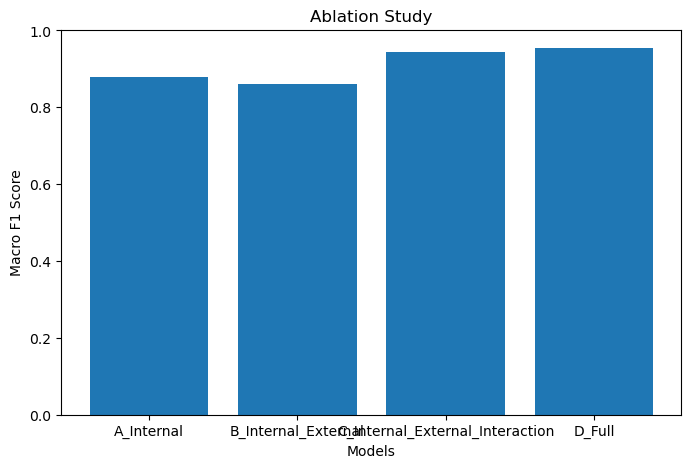

In [50]:
plt.figure(figsize=(8,5))

plt.bar(
    results['Model'],
    results['Macro_F1']
)

plt.ylabel("Macro F1 Score")
plt.xlabel("Models")
plt.title("Ablation Study")
plt.savefig("C:/Users/kulal/OneDrive/Documents/Infotact Solution/Predictive_Maintainance/Images/ablation_results.png")

plt.show()

Saving the results

In [51]:
results.to_csv(
    "C:/Users/kulal/OneDrive/Documents/Infotact Solution/Predictive_Maintainance/Dataset/ablation_results.csv",
    index=False
)

combined_df.to_csv(
    "C:/Users/kulal/OneDrive/Documents/Infotact Solution/Predictive_Maintainance/Dataset/week2_processed.csv",
    index=False
)

# WEEK 3 :

Loading Week 2 Dataset

In [52]:
df3=pd.read_csv("C:/Users/kulal/OneDrive/Documents/Infotact Solution/Predictive_Maintainance/Dataset/week2_processed.csv")


In [54]:
print(df3.shape)

print(df3['Machine failure'].value_counts())

(9530, 41)
Machine failure
0    9267
1     263
Name: count, dtype: int64


Creating Features and Target

In [55]:
X = df3.drop("Machine failure", axis=1)

y = df3["Machine failure"]

Checking Class Imbalance

In [56]:
print(y.value_counts())

print(y.value_counts(normalize=True)*100)

Machine failure
0    9267
1     263
Name: count, dtype: int64
Machine failure
0    97.240294
1     2.759706
Name: proportion, dtype: float64


Creating Stratified 5-Fold CV

In [57]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

Initialize LightGBM

In [58]:
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    random_state=42
)